In [2]:
import pandas as pd 
import numpy as np 
import requests
from bs4 import BeautifulSoup

In [6]:
webpage = requests.get('https://www.daraz.com.np/laptops/').text

In [7]:
soup = BeautifulSoup(webpage, 'lxml')

<!DOCTYPE html>
<html lang="en">
 <head>
  <meta charset="utf-8"/>
  <meta content="a2a0e" name="data-spm"/>
  <meta content="ie=edge" http-equiv="x-ua-compatible"/>
  <meta content="width=device-width" name="viewport"/>
  <meta content="origin" name="referrer"/>
  <meta content="assetPerf,imagesPerf" name="lzd-itrace-close-auto-monitor"/>
  <meta content="sg.mmstat.com" name="aplus-rhost-v"/>
  <meta content="sg.mmstat.com" name="aplus-rhost-g"/>
  <meta content='{"daraz_web_version":"2.0.0"}' name="aplus-cpvdata"/>
  <meta content='{"daraz_web_version":"2.0.0"}' name="aplus-exdata"/>
  <link href="//cart.daraz.com.np" rel="preconnect dns-prefetch"/>
  <link href="//member.daraz.com.np" rel="preconnect dns-prefetch"/>
  <link href="//acs-m.daraz.com.np" rel="preconnect dns-prefetch"/>
  <link href="//laz-img-cdn.alicdn.com" rel="preconnect dns-prefetch"/>
  <link href="//g.alicdn.com" rel="preconnect dns-prefetch"/>
  <link href="//g.lazcdn.com" rel="preconnect dns-prefetch"/>
  <link
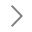

In [8]:
print(soup.prettify())

In [35]:
# soup.find_all('h1')[0].text

In [11]:
h1 = soup.find('h1')
if h1:
    print(h1.text.strip())
else:
    print("No <h1> tag found")


No <h1> tag found


In [12]:
pip install selenium webdriver-manager pandas


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.chrome.service import Service
import time
import pandas as pd

# Setup browser
options = webdriver.ChromeOptions()
options.add_argument("--start-maximized")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
)

url = "https://www.daraz.com.np/laptops/"
driver.get(url)
time.sleep(6)  # allow JS to load products

products = driver.find_elements(By.CSS_SELECTOR, "div.c2prKC")

data = []

for p in products:
    try:
        title = p.find_element(By.CSS_SELECTOR, "div.c16H9d a").text
    except:
        title = None

    try:
        price = p.find_element(By.CSS_SELECTOR, "span.c3gUW0").text
    except:
        price = None

    try:
        rating = p.find_element(By.CSS_SELECTOR, "span.c3Ve-Yr").text
    except:
        rating = None

    try:
        reviews = p.find_element(By.CSS_SELECTOR, "span.c3XbGJ").text
    except:
        reviews = None

    # Brand inference (first word of title)
    brand = title.split()[0] if title else None

    data.append({
        "Brand": brand,
        "Price": price,
        "Rating": rating,
        "Reviews": reviews,
        "Title": title
    })

driver.quit()

df = pd.DataFrame(data)
df.to_csv("daraz_laptops.csv", index=False)

print("✅ Data saved to daraz_laptops.csv")


✅ Data saved to daraz_laptops.csv


In [14]:
import pandas as pd 
import numpy as np 

In [36]:
# df = pd.read_csv('daraz_laptops.csv')

In [16]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
import pandas as pd
import time
import re

# ---------------- Browser Setup ----------------
options = webdriver.ChromeOptions()
options.add_argument("--disable-blink-features=AutomationControlled")
options.add_argument(
    "user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
    "AppleWebKit/537.36 (KHTML, like Gecko) "
    "Chrome/120.0.0.0 Safari/537.36"
)

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
)

BASE_URL = "https://www.daraz.com.np/laptops/?page="
page = 1
laptop_nbr = 1
data = []

print("🚀 Starting unlimited laptop scraping...")

while True:
    print(f"Scraping page {page}...")
    driver.get(BASE_URL + str(page))

    try:
        WebDriverWait(driver, 15).until(
            EC.presence_of_element_located((By.CSS_SELECTOR, "div.c2prKC"))
        )
    except:
        print("❌ No more products found. Stopping.")
        break

    products = driver.find_elements(By.CSS_SELECTOR, "div.c2prKC")

    if not products:
        break

    for p in products:
        # Brand (from title)
        try:
            title = p.find_element(By.CSS_SELECTOR, "div.c16H9d a").text
            brand = title.split()[0]
        except:
            brand = None

        # Price
        try:
            price_text = p.find_element(By.CSS_SELECTOR, "span.c3gUW0").text
            price = int(re.sub(r"[^\d]", "", price_text))
        except:
            continue

        # Rating
        try:
            rating = p.find_element(By.CSS_SELECTOR, "span.c3Ve-Yr").text
        except:
            rating = None

        # Review count
        try:
            review = p.find_element(By.CSS_SELECTOR, "span.c3XbGJ").text
        except:
            review = None

        data.append({
            "laptop_nbr": laptop_nbr,
            "brand": brand,
            "price": price,
            "rating": rating,
            "review": review
        })

        laptop_nbr += 1

    page += 1
    time.sleep(2)  # anti-blocking delay

driver.quit()

# ---------------- Save CSV ----------------
if data:
    df = pd.DataFrame(data)
    df.to_csv("daraz_laptops_all_with_nbr.csv", index=False)
    print("✅ Finished. Total laptops scraped:", len(df))
else:
    print("❌ No data scraped.")



🚀 Starting unlimited laptop scraping...
Scraping page 1...
❌ No more products found. Stopping.
❌ No data scraped.


In [17]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
import pandas as pd
import time
import re

# ---------------- Browser Setup ----------------
options = webdriver.ChromeOptions()
options.add_argument("--disable-blink-features=AutomationControlled")
options.add_argument(
    "user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
    "AppleWebKit/537.36 (KHTML, like Gecko) "
    "Chrome/120.0.0.0 Safari/537.36"
)

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
)

BASE_URL = "https://www.daraz.com.np/laptops/?page="
page = 1
laptop_nbr = 1
MAX_LAPTOPS = 10000
data = []

print("🚀 Scraping up to 10,000 laptops...")

# ---------------- Scraping Loop ----------------
while laptop_nbr <= MAX_LAPTOPS:
    print(f"Scraping page {page}...")
    driver.get(BASE_URL + str(page))

    try:
        WebDriverWait(driver, 15).until(
            EC.presence_of_element_located((By.CSS_SELECTOR, "div.c2prKC"))
        )
    except:
        print("❌ No more products found.")
        break

    products = driver.find_elements(By.CSS_SELECTOR, "div.c2prKC")

    if not products:
        break

    for p in products:
        if laptop_nbr > MAX_LAPTOPS:
            break

        # Brand (from title)
        try:
            title = p.find_element(By.CSS_SELECTOR, "div.c16H9d a").text
            brand = title.split()[0]
        except:
            brand = None

        # Price
        try:
            price_text = p.find_element(By.CSS_SELECTOR, "span.c3gUW0").text
            price = int(re.sub(r"[^\d]", "", price_text))
        except:
            continue

        # Rating
        try:
            rating = p.find_element(By.CSS_SELECTOR, "span.c3Ve-Yr").text
        except:
            rating = None

        # Review count
        try:
            review = p.find_element(By.CSS_SELECTOR, "span.c3XbGJ").text
        except:
            review = None

        data.append({
            "laptop_nbr": laptop_nbr,
            "brand": brand,
            "price": price,
            "rating": rating,
            "review": review
        })

        laptop_nbr += 1

    page += 1
    time.sleep(2)  # anti-blocking delay

driver.quit()

# ---------------- Save CSV ----------------
if data:
    df = pd.DataFrame(data)
    df.to_csv("daraz_laptops_upto_10000.csv", index=False)
    print(f"✅ Done. Total laptops saved: {len(df)}")
else:
    print("❌ No data scraped.")


🚀 Scraping up to 10,000 laptops...
Scraping page 1...
❌ No more products found.
❌ No data scraped.


In [18]:
pip install requests pandas


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import requests
import pandas as pd
import time

BASE_URL = "https://www.daraz.com.np/catalog/"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36"
}

all_rows = []
laptop_nbr = 1

# 🔹 STOP AT PAGE 20
for page in range(1, 21):
    print(f"Scraping page {page}...")

    params = {
        "ajax": "true",
        "page": page,
        "q": "laptop"
    }

    response = requests.get(BASE_URL, headers=headers, params=params)

    if response.status_code != 200:
        print("❌ Request blocked or failed. Stopping.")
        break

    data = response.json()
    items = data.get("mods", {}).get("listItems", [])

    if not items:
        print("⚠ No items found. Stopping early.")
        break

    for item in items:
        all_rows.append({
            "laptop_nbr": laptop_nbr,
            "item_id": item.get("itemId"),
            "name": item.get("name"),
            "brand": item.get("brandName"),
            "price": item.get("price"),
            "rating": item.get("ratingScore"),
            "review": item.get("review")
        })
        laptop_nbr += 1

    time.sleep(1)  # polite delay

df = pd.DataFrame(all_rows)
df.to_csv("daraz_laptops_page_1_to_20.csv", index=False)

print("✅ Done")
print("Total laptops scraped:", df.shape[0])
print(df.head())


Scraping page 1...
Scraping page 2...
Scraping page 3...
Scraping page 4...
Scraping page 5...
Scraping page 6...
Scraping page 7...
Scraping page 8...
Scraping page 9...
Scraping page 10...
Scraping page 11...
Scraping page 12...
Scraping page 13...
Scraping page 14...
Scraping page 15...
Scraping page 16...
Scraping page 17...
Scraping page 18...
Scraping page 19...
Scraping page 20...
✅ Done
Total laptops scraped: 800
   laptop_nbr    item_id                                               name  \
0           1  183906479  Laptop Dell Latitude 5300 , Laptop 13.3" Intel...   
1           2  496127676  Dell Wyse 5470 Thin Client Laptop Intel Celero...   
2           3  511961371  DELL inspiron 15 AMD Ryzen 5 Quad Core 7520U -...   
3           4  511941121  HP VICTUS 15 I5 13TH GEN 13420H 8GB RAM 512GB ...   
4           5  156116586  Acer NITRO V 16 AMD Ryzen 7 8845HS RTX 3050 6G...   

      brand   price             rating review  
0  No Brand   39450  4.666666666666667     21  
1  N

In [21]:
df = pd.read_csv(r'C:\Users\acer\OneDrive\Desktop\60_DaysOf_ML\02-Supervised-Learning\code\daraz_laptops_page_1_to_20.csv')

In [22]:
df.head()

,laptop_nbr,item_id,name,brand,price,rating,review
0,1,183906479,"Laptop Dell Latitude 5300 , Laptop 13.3"" Intel...",No Brand,39450.0,4.666667,21.0
1,2,496127676,Dell Wyse 5470 Thin Client Laptop Intel Celero...,No Brand,33199.0,5.000000,1.0
2,3,511961371,DELL inspiron 15 AMD Ryzen 5 Quad Core 7520U -...,No Brand,78100.0,NaN,NaN
3,4,511941121,HP VICTUS 15 I5 13TH GEN 13420H 8GB RAM 512GB ...,NaN,102500.0,NaN,NaN
4,5,156116586,Acer NITRO V 16 AMD Ryzen 7 8845HS RTX 3050 6G...,No Brand,133999.0,5.000000,1.0


In [23]:
df.shape

(800, 7)

In [24]:
df.size

5600

In [25]:
df.describe()

,laptop_nbr,item_id,price,rating,review
count,800.0000,8.000000e+02,800.000000,521.000000,526.000000
mean,400.5000,2.601486e+08,47829.265550,4.454630,68.633080
std,231.0844,1.728047e+08,80779.327545,0.520854,156.557856
min,1.0000,2.818200e+04,29.000000,1.000000,0.000000
25%,200.7500,1.238140e+08,313.500000,4.296296,5.000000
50%,400.5000,1.457847e+08,1120.000000,4.529412,19.500000
75%,600.2500,4.806039e+08,88999.000000,4.750000,75.500000
max,800.0000,5.127726e+08,633900.000000,5.000000,2539.000000


In [26]:
df.isnull()

,laptop_nbr,item_id,name,brand,price,rating,review
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,True,True
3,False,False,False,True,False,True,True
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
795,False,False,False,False,False,False,False
796,False,False,False,False,False,False,False
797,False,False,False,False,False,False,False
798,False,False,False,False,False,False,False


In [27]:
df.isnull().mean()

laptop_nbr    0.00000
item_id       0.00000
name          0.00000
brand         0.07375
price         0.00000
rating        0.34875
review        0.34250
dtype: float64

In [28]:
df.isnull().sum()

laptop_nbr      0
item_id         0
name            0
brand          59
price           0
rating        279
review        274
dtype: int64

In [29]:
df.dropna(inplace = True)

In [30]:
df.isnull().sum()

laptop_nbr    0
item_id       0
name          0
brand         0
price         0
rating        0
review        0
dtype: int64

In [31]:
df.head()

,laptop_nbr,item_id,name,brand,price,rating,review
0,1,183906479,"Laptop Dell Latitude 5300 , Laptop 13.3"" Intel...",No Brand,39450.0,4.666667,21.0
1,2,496127676,Dell Wyse 5470 Thin Client Laptop Intel Celero...,No Brand,33199.0,5.000000,1.0
4,5,156116586,Acer NITRO V 16 AMD Ryzen 7 8845HS RTX 3050 6G...,No Brand,133999.0,5.000000,1.0
5,6,488108320,Great Asia TkE-140C | 16/256 | SSD | HD display,No Brand,38958.0,4.000000,2.0
9,10,129691037,Acer Aspire lite Core 3 N355 -13th Gen 8GB RAM...,No Brand,58897.0,5.000000,1.0


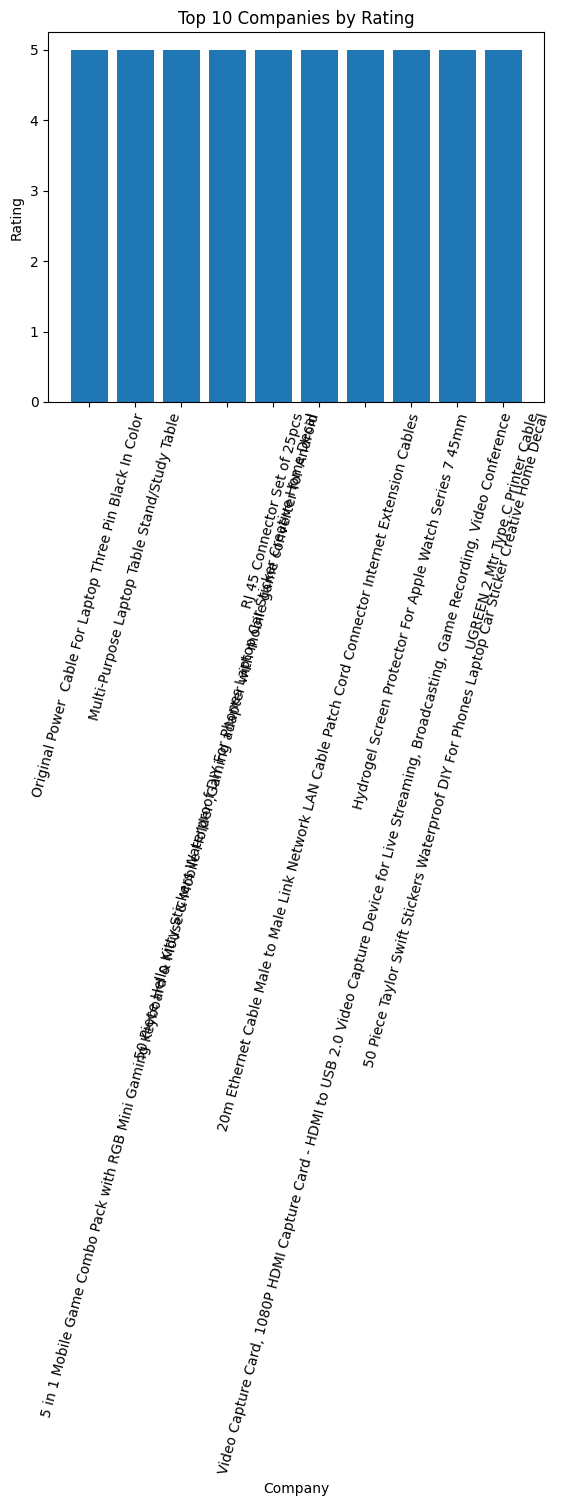

In [34]:
import matplotlib.pyplot as plt

# top 10 companies by rating
top_companies = df.sort_values("rating", ascending=False).head(10)

plt.figure()
plt.bar(top_companies["name"], top_companies["rating"])

plt.xticks(rotation=75)
plt.xlabel("Company")
plt.ylabel("Rating")
plt.title("Top 10 Companies by Rating")

plt.show()